## Revise

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


!gdown 1bwRmKkPwmLKiqOgQ_LnKH0Vsc3mJKmVR

Downloading...
From: https://drive.google.com/uc?id=1bwRmKkPwmLKiqOgQ_LnKH0Vsc3mJKmVR
To: /content/cars24-car-price-cleaned.csv
100% 1.69M/1.69M [00:00<00:00, 101MB/s]


In [2]:
df = pd.read_csv('cars24-car-price-cleaned.csv')
df.head()

,selling_price,year,km_driven,mileage,engine,max_power,age,make,model,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,5,>5
0,1.20,2012.0,120000,19.70,796.0,46.30,11.0,MARUTI,ALTO STD,1,0,0,0,0,1,1,1,0
1,5.50,2016.0,20000,18.90,1197.0,82.00,7.0,HYUNDAI,GRAND I10 ASTA,1,0,0,0,0,1,1,1,0
2,2.15,2010.0,60000,17.00,1197.0,80.00,13.0,HYUNDAI,I20 ASTA,1,0,0,0,0,1,1,1,0
3,2.26,2012.0,37000,20.92,998.0,67.10,11.0,MARUTI,ALTO K10 2010-2014 VXI,1,0,0,0,0,1,1,1,0
4,5.70,2015.0,30000,22.77,1498.0,98.59,8.0,FORD,ECOSPORT 2015-2021 1.5 TDCI TITANIUM BSIV,0,0,1,0,0,0,1,1,0


In [3]:
df['make'] = df.groupby('make')['selling_price'].transform('mean')
df['model'] = df.groupby('model')['selling_price'].transform('mean')

In [4]:
df.head()

,selling_price,year,km_driven,mileage,engine,max_power,age,make,model,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,5,>5
0,1.20,2012.0,120000,19.70,796.0,46.30,11.0,4.684721,1.180000,1,0,0,0,0,1,1,1,0
1,5.50,2016.0,20000,18.90,1197.0,82.00,7.0,5.458819,4.818750,1,0,0,0,0,1,1,1,0
2,2.15,2010.0,60000,17.00,1197.0,80.00,13.0,5.458819,3.394000,1,0,0,0,0,1,1,1,0
3,2.26,2012.0,37000,20.92,998.0,67.10,11.0,4.684721,2.242676,1,0,0,0,0,1,1,1,0
4,5.70,2015.0,30000,22.77,1498.0,98.59,8.0,5.858258,6.777576,0,0,1,0,0,0,1,1,0


In [5]:
from sklearn.model_selection import train_test_split


df_train, df_test = train_test_split(df, test_size=0.3)

## Scale the data

In [6]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

In [7]:
scaler.fit_transform(df_train)

array([[0.27423856, 0.75862069, 0.07180582, ..., 0.        , 1.        ,
        0.        ],
       [0.25239655, 0.79310345, 0.08652658, ..., 1.        , 0.        ,
        1.        ],
       [0.08202888, 0.65517241, 0.03921789, ..., 1.        , 1.        ,
        0.        ],
       ...,
       [0.12377139, 0.72413793, 0.05607372, ..., 1.        , 1.        ,
        0.        ],
       [0.2159932 , 0.72413793, 0.06169232, ..., 1.        , 1.        ,
        0.        ],
       [0.23540832, 0.72413793, 0.08866165, ..., 1.        , 1.        ,
        0.        ]])

In [8]:
df_train = pd.DataFrame(scaler.fit_transform(df_train), columns=df.columns)

df_test = pd.DataFrame(scaler.transform(df_test), columns=df.columns)

In [9]:
df_train

,selling_price,year,km_driven,mileage,engine,max_power,age,make,model,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,5,>5
0,0.274239,0.758621,0.071806,0.134569,0.216380,0.166667,0.241379,0.190427,0.347467,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.252397,0.793103,0.086527,0.103621,0.203347,0.142834,0.206897,0.194048,0.271656,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0
2,0.082029,0.655172,0.039218,0.147414,0.184834,0.110950,0.344828,0.194048,0.137751,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
3,0.315496,0.827586,0.071806,0.136810,0.216380,0.126892,0.172414,0.190168,0.338615,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
4,0.737775,0.689655,0.033599,0.092586,0.443276,0.428180,0.310345,0.964468,0.897892,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13869,0.259677,0.793103,0.038679,0.103621,0.203347,0.142834,0.206897,0.194048,0.280209,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0
13870,0.322776,0.793103,0.058321,0.171552,0.234301,0.195169,0.206897,0.232517,0.323217,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
13871,0.123771,0.724138,0.056074,0.141034,0.177281,0.119002,0.275862,0.232517,0.126757,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
13872,0.215993,0.724138,0.061692,0.153448,0.216380,0.117552,0.275862,0.190168,0.211396,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0


In [10]:
y_train = df_train['selling_price']
X_train = df_train.drop('selling_price', axis=1)

y_test = df_test['selling_price']
X_test = df_test.drop('selling_price', axis=1)

## Linear regression

In [11]:
from sklearn.linear_model import LinearRegression


lr = LinearRegression()

In [12]:
lr

LinearRegression()

In [13]:
lr.fit(X_train, y_train)

LinearRegression()

In [14]:
lr.coef_

array([ 0.12313118, -0.14428914, -0.24342648,  0.09157183,  0.04571356,
       -0.12313118,  0.07042896,  0.85111653, -0.00534596, -0.00744008,
        0.00674739,  0.13269594,  0.01944445, -0.00853152, -0.00447972,
       -0.01063945, -0.02038684])

In [15]:
lr.intercept_

np.float64(-0.009404397419099542)

In [16]:
X_test

,year,km_driven,mileage,engine,max_power,age,make,model,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,5,>5
0,0.827586,0.012249,0.125862,0.177281,0.123720,0.172414,0.232517,0.251002,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
1,0.689655,0.071662,0.125000,0.177281,0.120773,0.310345,0.232517,0.146600,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
2,0.793103,0.033599,0.182500,0.118335,0.077778,0.206897,0.190168,0.137106,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
3,0.862069,0.016743,0.142328,0.147808,0.099839,0.137931,0.194048,0.191210,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,0.862069,0.041971,0.113879,0.177281,0.158615,0.137931,0.236566,0.307375,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5941,0.896552,0.039218,0.144224,0.203347,0.138647,0.103448,0.194048,0.373898,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
5942,0.862069,0.057254,0.135086,0.234301,0.195169,0.137931,0.232517,0.478870,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
5943,0.896552,0.076301,0.185345,0.221860,0.150725,0.103448,0.258412,0.391979,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
5944,0.827586,0.022376,0.153362,0.147808,0.099919,0.172414,0.194048,0.146016,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0


In [17]:
y_hat = lr.predict(X_test)

In [18]:
y_hat

array([0.2671093 , 0.13578619, 0.12898404, ..., 0.4027784 , 0.16310164,
       0.48728543])

In [19]:
y_test

,selling_price
0,0.264531
1,0.155321
2,0.082514
3,0.230555
4,0.419852
...,...
5941,0.373741
5942,0.495086
5943,0.448975
5944,0.179590


In [20]:
r2 = lr.score(X_test, y_test)

In [21]:
X_test.shape

(5946, 17)

In [22]:
m = len(X_test)


In [23]:
d = X_test.shape[1]

In [24]:
adj_r2 = 1 - (1-r2)*(m-1)/(m-d-1)

In [25]:
adj_r2

0.9457643894331653

In [26]:
r2

0.9459194786475701

## Solving Via statsmodel

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

!gdown 1UpLnYA48Vy_lGUMMLG-uQE1gf_Je12Lh

Downloading...
From: https://drive.google.com/uc?id=1UpLnYA48Vy_lGUMMLG-uQE1gf_Je12Lh
To: /content/cars24-car-price-clean.csv
100% 7.10M/7.10M [00:00<00:00, 38.3MB/s]


In [28]:
df = pd.read_csv('cars24-car-price-clean.csv')
df.head()

,selling_price,year,km_driven,mileage,engine,max_power,age,make,model,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,5,>5
0,-1.111046,-0.801317,1.195828,0.045745,-1.310754,-1.157780,0.801317,-0.433854,-1.125683,1.248892,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
1,-0.223944,0.450030,-0.737872,-0.140402,-0.537456,-0.360203,-0.450030,-0.327501,-0.333227,1.248892,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
2,-0.915058,-1.426990,0.035608,-0.582501,-0.537456,-0.404885,1.426990,-0.327501,-0.789807,1.248892,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
3,-0.892365,-0.801317,-0.409143,0.329620,-0.921213,-0.693085,0.801317,-0.433854,-0.905265,1.248892,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
4,-0.182683,0.137194,-0.544502,0.760085,0.042999,0.010435,-0.137194,-0.246579,-0.013096,-0.800710,-0.098382,1.014945,-0.020095,-0.056917,-0.975970,0.495818,0.444503,-0.424728


In [29]:
y=df[['selling_price']]
X=df.drop('selling_price', axis=1)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)
y_train = np.array(y_train)

In [30]:
import statsmodels.api as sm

In [31]:
X_train

,year,km_driven,mileage,engine,max_power,age,make,model,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,5,>5
3443,-0.488480,0.170967,-0.908259,0.041071,0.406096,0.488480,-0.177218,-0.432940,-0.800710,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,-2.016868,0.444503,-0.424728
16090,0.762867,-0.447817,0.234219,-0.921213,-0.694426,-0.762867,-0.433854,-0.548397,1.248892,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
11070,0.450030,1.389198,0.483191,-0.439107,-0.210518,-0.450030,-0.639625,-0.453932,1.248892,-0.098382,1.014945,-0.020095,-0.056917,-0.975970,-2.016868,0.444503,-0.424728
19214,1.075704,-0.287977,-0.312588,-0.539385,-0.252966,-1.075704,-0.246579,-0.275499,-0.800710,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
17843,-1.114153,-0.196436,-0.768649,0.033357,0.265347,1.114153,-0.327501,-0.695343,1.248892,-0.098382,1.014945,-0.020095,-0.056917,-0.975970,0.495818,0.444503,-0.424728
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1099,1.388540,-0.559005,-1.355012,1.768939,1.109840,-1.388540,0.724475,2.432495,-0.800710,-0.098382,1.014945,-0.020095,-0.056917,-0.975970,0.495818,-2.249703,2.354446
18898,1.075704,-0.764944,0.580918,-0.537456,-0.364671,-1.075704,-0.433854,-0.432940,1.248892,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
11798,0.450030,-0.302209,-0.980391,0.222343,0.517801,-0.450030,-0.327501,0.391004,-0.800710,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
6637,-0.488480,-0.834557,-0.145056,1.001426,1.918587,0.488480,3.360773,2.820851,-0.800710,-0.098382,1.014945,-0.020095,-0.056917,-0.975970,-2.016868,0.444503,-0.424728


In [32]:
## do one extra step

X_sm = sm.add_constant(X_train)

In [33]:
X_sm

,const,year,km_driven,mileage,engine,max_power,age,make,model,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,5,>5
3443,1.0,-0.488480,0.170967,-0.908259,0.041071,0.406096,0.488480,-0.177218,-0.432940,-0.800710,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,-2.016868,0.444503,-0.424728
16090,1.0,0.762867,-0.447817,0.234219,-0.921213,-0.694426,-0.762867,-0.433854,-0.548397,1.248892,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
11070,1.0,0.450030,1.389198,0.483191,-0.439107,-0.210518,-0.450030,-0.639625,-0.453932,1.248892,-0.098382,1.014945,-0.020095,-0.056917,-0.975970,-2.016868,0.444503,-0.424728
19214,1.0,1.075704,-0.287977,-0.312588,-0.539385,-0.252966,-1.075704,-0.246579,-0.275499,-0.800710,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
17843,1.0,-1.114153,-0.196436,-0.768649,0.033357,0.265347,1.114153,-0.327501,-0.695343,1.248892,-0.098382,1.014945,-0.020095,-0.056917,-0.975970,0.495818,0.444503,-0.424728
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1099,1.0,1.388540,-0.559005,-1.355012,1.768939,1.109840,-1.388540,0.724475,2.432495,-0.800710,-0.098382,1.014945,-0.020095,-0.056917,-0.975970,0.495818,-2.249703,2.354446
18898,1.0,1.075704,-0.764944,0.580918,-0.537456,-0.364671,-1.075704,-0.433854,-0.432940,1.248892,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
11798,1.0,0.450030,-0.302209,-0.980391,0.222343,0.517801,-0.450030,-0.327501,0.391004,-0.800710,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
6637,1.0,-0.488480,-0.834557,-0.145056,1.001426,1.918587,0.488480,3.360773,2.820851,-0.800710,-0.098382,1.014945,-0.020095,-0.056917,-0.975970,-2.016868,0.444503,-0.424728


In [34]:
model = sm.OLS(y_train, X_sm)


results = model.fit()

In [35]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.941
Model:                            OLS   Adj. R-squared:                  0.941
Method:                 Least Squares   F-statistic:                 1.588e+04
Date:                Wed, 10 Sep 2025   Prob (F-statistic):               0.00
Time:                        16:20:01   Log-Likelihood:                -7.3180
No. Observations:               15856   AIC:                             48.64
Df Residuals:                   15839   BIC:                             179.0
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             7.664e-05      0.002  

In [36]:
import numpy as np
import statsmodels.api as sm

# fake data
X = np.array([1, 2, 3, 4, 5])
y = np.array([2.2, 2.8, 4.9, 5.1, 7.2])

In [37]:
# Without constant
model_no_const = sm.OLS(y, X).fit()
print("Without intercept:\n", model_no_const.params)

Without intercept:
 [1.43454545]


In [38]:

X_const = sm.add_constant(X)
X_const

array([[1., 1.],
       [1., 2.],
       [1., 3.],
       [1., 4.],
       [1., 5.]])

In [39]:
model_const = sm.OLS(y, X_const).fit()

In [40]:
# With constant


print("\nWith intercept:\n", model_const.params)


With intercept:
 [0.75 1.23]


## Without Pipeline

## Implementing VIF -

## Homework - Manual approach

In [42]:
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [43]:
X = df[df.columns.drop('selling_price')]
y = df["selling_price"]

In [44]:
X

,year,km_driven,mileage,engine,max_power,age,make,model,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,5,>5
0,-0.801317,1.195828,0.045745,-1.310754,-1.157780,0.801317,-0.433854,-1.125683,1.248892,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
1,0.450030,-0.737872,-0.140402,-0.537456,-0.360203,-0.450030,-0.327501,-0.333227,1.248892,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
2,-1.426990,0.035608,-0.582501,-0.537456,-0.404885,1.426990,-0.327501,-0.789807,1.248892,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
3,-0.801317,-0.409143,0.329620,-0.921213,-0.693085,0.801317,-0.433854,-0.905265,1.248892,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
4,0.137194,-0.544502,0.760085,0.042999,0.010435,-0.137194,-0.246579,-0.013096,-0.800710,-0.098382,1.014945,-0.020095,-0.056917,-0.975970,0.495818,0.444503,-0.424728
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19815,0.762867,0.218923,0.950886,-0.215410,-0.694202,-0.762867,0.724475,0.091865,-0.800710,-0.098382,1.014945,-0.020095,-0.056917,-0.975970,0.495818,0.444503,-0.424728
19816,1.388540,-0.776546,-0.466159,-0.198054,-0.156899,-1.388540,-0.433854,0.112857,-0.800710,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,-2.249703,2.354446
19817,0.137194,0.170967,0.380810,0.042999,0.120577,-0.137194,-0.240799,-0.448684,-0.800710,-0.098382,1.014945,-0.020095,-0.056917,-0.975970,0.495818,0.444503,-0.424728
19818,0.450030,72.355997,-0.815185,1.356256,0.935579,-0.450030,0.123346,0.328027,-0.800710,-0.098382,1.014945,-0.020095,-0.056917,-0.975970,0.495818,-2.249703,2.354446


In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)


In [46]:
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_train)

In [47]:
X_tr_scaled

array([[-0.48695362,  0.15876399, -0.89685782, ..., -2.02323478,
         0.4484653 , -0.42801318],
       [ 0.76343287, -0.42916149,  0.23102856, ...,  0.49425801,
         0.4484653 , -0.42801318],
       [ 0.45083625,  1.31624227,  0.47682051, ..., -2.02323478,
         0.4484653 , -0.42801318],
       ...,
       [ 0.45083625, -0.29081528, -0.96806857, ...,  0.49425801,
         0.4484653 , -0.42801318],
       [-0.48695362, -0.79661492, -0.14340215, ..., -2.02323478,
         0.4484653 , -0.42801318],
       [-0.174357  , -0.53939752, -1.03468508, ...,  0.49425801,
         0.4484653 , -0.42801318]])

In [48]:
X_sm = sm.add_constant(X_tr_scaled)
X_sm #Statmodels default is without intercept, to add intercept we need to add constant

array([[ 1.        , -0.48695362,  0.15876399, ..., -2.02323478,
         0.4484653 , -0.42801318],
       [ 1.        ,  0.76343287, -0.42916149, ...,  0.49425801,
         0.4484653 , -0.42801318],
       [ 1.        ,  0.45083625,  1.31624227, ..., -2.02323478,
         0.4484653 , -0.42801318],
       ...,
       [ 1.        ,  0.45083625, -0.29081528, ...,  0.49425801,
         0.4484653 , -0.42801318],
       [ 1.        , -0.48695362, -0.79661492, ..., -2.02323478,
         0.4484653 , -0.42801318],
       [ 1.        , -0.174357  , -0.53939752, ...,  0.49425801,
         0.4484653 , -0.42801318]])

In [49]:
sm_model = sm.OLS(y_train, X_sm).fit()

In [50]:
print(sm_model.summary())

                            OLS Regression Results                            
Dep. Variable:          selling_price   R-squared:                       0.941
Model:                            OLS   Adj. R-squared:                  0.941
Method:                 Least Squares   F-statistic:                 1.588e+04
Date:                Wed, 10 Sep 2025   Prob (F-statistic):               0.00
Time:                        16:24:46   Log-Likelihood:                -7.3180
No. Observations:               15856   AIC:                             48.64
Df Residuals:                   15839   BIC:                             179.0
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0004      0.002     -0.223      0.8

## Check Variance Inflation Factor

In [51]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [52]:
vif = pd.DataFrame()
vif

""


In [53]:
X_t = pd.DataFrame(X_tr_scaled, columns=X_train.columns)
X_t

,year,km_driven,mileage,engine,max_power,age,make,model,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,5,>5
0,-0.486954,0.158764,-0.896858,0.040307,0.404950,0.486954,-0.178317,-0.433228,-0.803747,-0.100003,-0.986220,-0.021016,-0.058458,1.025553,-2.023235,0.448465,-0.428013
1,0.763433,-0.429161,0.231029,-0.922002,-0.692532,-0.763433,-0.435189,-0.548862,1.244173,-0.100003,-0.986220,-0.021016,-0.058458,1.025553,0.494258,0.448465,-0.428013
2,0.450836,1.316242,0.476821,-0.439884,-0.209961,-0.450836,-0.641149,-0.454252,1.244173,-0.100003,1.013972,-0.021016,-0.058458,-0.975083,-2.023235,0.448465,-0.428013
3,1.076029,-0.277293,-0.308795,-0.540164,-0.252291,-1.076029,-0.247742,-0.275545,-0.803747,-0.100003,-0.986220,-0.021016,-0.058458,1.025553,0.494258,0.448465,-0.428013
4,-1.112147,-0.190317,-0.759031,0.032593,0.264590,1.112147,-0.328737,-0.696032,1.244173,-0.100003,1.013972,-0.021016,-0.058458,-0.975083,0.494258,0.448465,-0.428013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15851,1.388626,-0.534804,-1.337905,1.768220,1.106750,-1.388626,0.724205,2.436597,-0.803747,-0.100003,1.013972,-0.021016,-0.058458,-0.975083,0.494258,-2.229827,2.336377
15852,1.076029,-0.730473,0.573300,-0.538236,-0.363688,-1.076029,-0.435189,-0.433228,1.244173,-0.100003,-0.986220,-0.021016,-0.058458,1.025553,0.494258,0.448465,-0.428013
15853,0.450836,-0.290815,-0.968069,0.221583,0.516347,-0.450836,-0.328737,0.391978,-0.803747,-0.100003,-0.986220,-0.021016,-0.058458,1.025553,0.494258,0.448465,-0.428013
15854,-0.486954,-0.796615,-0.143402,1.000687,1.913264,0.486954,3.362926,2.825548,-0.803747,-0.100003,1.013972,-0.021016,-0.058458,-0.975083,-2.023235,0.448465,-0.428013


In [54]:
vif

""


In [55]:
vif['Features'] = X_t.columns

In [56]:
vif

,Features
0,year
1,km_driven
2,mileage
3,engine
4,max_power
5,age
6,make
7,model
8,Individual
9,Trustmark Dealer


In [57]:
X_t.values

array([[-0.48695362,  0.15876399, -0.89685782, ..., -2.02323478,
         0.4484653 , -0.42801318],
       [ 0.76343287, -0.42916149,  0.23102856, ...,  0.49425801,
         0.4484653 , -0.42801318],
       [ 0.45083625,  1.31624227,  0.47682051, ..., -2.02323478,
         0.4484653 , -0.42801318],
       ...,
       [ 0.45083625, -0.29081528, -0.96806857, ...,  0.49425801,
         0.4484653 , -0.42801318],
       [-0.48695362, -0.79661492, -0.14340215, ..., -2.02323478,
         0.4484653 , -0.42801318],
       [-0.174357  , -0.53939752, -1.03468508, ...,  0.49425801,
         0.4484653 , -0.42801318]])

In [59]:
X_t.columns

Index(['year', 'km_driven', 'mileage', 'engine', 'max_power', 'age', 'make',
       'model', 'Individual', 'Trustmark Dealer', 'Diesel', 'Electric', 'LPG',
       'Petrol', 'Manual', '5', '>5'],
      dtype='object')

In [60]:
variance_inflation_factor(X_t.values, 2)

np.float64(3.221178126323722)

In [61]:
vif['VIF'] = [variance_inflation_factor(X_t.values, i) for i in range(X_t.shape[1])]

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [62]:
vif

,Features,VIF
0,year,inf
1,km_driven,1.210257
2,mileage,3.221178
3,engine,6.256598
4,max_power,4.996432
5,age,inf
6,make,3.209627
7,model,5.777104
8,Individual,1.087117
9,Trustmark Dealer,1.021978


In [63]:
vif['VIF'] = round(vif['VIF'], 2)

In [64]:
vif = vif.sort_values(by = "VIF", ascending = False)
vif


,Features,VIF
0,year,inf
5,age,inf
13,Petrol,18.30
10,Diesel,17.30
16,>5,13.04
15,5,11.75
3,engine,6.26
7,model,5.78
4,max_power,5.00
2,mileage,3.22


In [68]:
cols2 = vif["Features"][1:].values

In [69]:
X2 = pd.DataFrame(X_tr_scaled, columns=X_train.columns)[cols2]

In [70]:
X2_sm = sm.add_constant(X2)

In [71]:
sm_model = sm.OLS(list(y_train), X2_sm).fit()

In [72]:
print(sm_model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.941
Model:                            OLS   Adj. R-squared:                  0.941
Method:                 Least Squares   F-statistic:                 1.588e+04
Date:                Wed, 10 Sep 2025   Prob (F-statistic):               0.00
Time:                        16:37:47   Log-Likelihood:                -7.3180
No. Observations:               15856   AIC:                             48.64
Df Residuals:                   15839   BIC:                             179.0
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -0.0004      0.002  

## Automated Way of fitting a clean, lean and good model

In [73]:
vif_thr = 6


In [74]:
r2_thr = 0.85

i = 1
feats_removed = ['year']

In [75]:
while True:
  vif = pd.DataFrame()
  X_t = pd.DataFrame(X_tr_scaled, columns=X_train.columns)[cols2]
  vif['Features'] = cols2
  vif['VIF'] = [variance_inflation_factor(X_t.values, i) for i in range(X_t.shape[1])]
  vif['VIF'] = round(vif['VIF'], 2)
  vif = vif.sort_values(by = "VIF", ascending = False)

  cols2 = vif["Features"][1:].values
  X2 = pd.DataFrame(X_tr_scaled, columns=X_train.columns)[cols2]

  X2_sm = sm.add_constant(X2)  #Statmodels default is without intercept, to add intercept we need to add constant
  sm_model = sm.OLS(list(y_train), X2_sm).fit()

  ## Check if we are there or not
  if (vif.iloc[0]['VIF'] < vif_thr) or (sm_model.rsquared_adj < r2_thr):
    print('Reached threshold')
    print('Highest vif:',vif.iloc[0])
    print('Current adj.R2',sm_model.rsquared_adj)
    print('Features removed:', i)
    print('List of features removed:', feats_removed)
    break
  feats_removed.append(vif.iloc[0]['Features'])
  i += 1

Reached threshold
Highest vif: Features    model
VIF          5.75
Name: 0, dtype: object
Current adj.R2 0.8318553555450336
Features removed: 4
List of features removed: ['year', 'Petrol', '>5', 'engine']


In [76]:
sm_model

In [77]:
print(vif)


            Features   VIF
0              model  5.75
1          max_power  3.31
2               make  3.16
3            mileage  2.28
5                age  1.88
6             Manual  1.77
4             Diesel  1.66
7                  5  1.47
9          km_driven  1.20
8           Electric  1.18
10        Individual  1.08
11  Trustmark Dealer  1.02
12               LPG  1.01


In [79]:
print(sm_model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.832
Model:                            OLS   Adj. R-squared:                  0.832
Method:                 Least Squares   F-statistic:                     6538.
Date:                Wed, 10 Sep 2025   Prob (F-statistic):               0.00
Time:                        16:43:44   Log-Likelihood:                -8348.2
No. Observations:               15856   AIC:                         1.672e+04
Df Residuals:                   15843   BIC:                         1.682e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -0.0004      0.003  

## Break

In [80]:
X_sm = sm.add_constant(X_tr_scaled)

In [81]:
X_sm

array([[ 1.        , -0.48695362,  0.15876399, ..., -2.02323478,
         0.4484653 , -0.42801318],
       [ 1.        ,  0.76343287, -0.42916149, ...,  0.49425801,
         0.4484653 , -0.42801318],
       [ 1.        ,  0.45083625,  1.31624227, ..., -2.02323478,
         0.4484653 , -0.42801318],
       ...,
       [ 1.        ,  0.45083625, -0.29081528, ...,  0.49425801,
         0.4484653 , -0.42801318],
       [ 1.        , -0.48695362, -0.79661492, ..., -2.02323478,
         0.4484653 , -0.42801318],
       [ 1.        , -0.174357  , -0.53939752, ...,  0.49425801,
         0.4484653 , -0.42801318]])

In [82]:
sm_model = sm.OLS(y_train, X_sm).fit()


In [83]:
y_train

,selling_price
3443,-0.378671
16090,-0.533398
11070,-0.461192
19214,-0.079532
17843,-0.688125
...,...
1099,2.664297
18898,-0.285834
11798,0.343389
6637,2.561145


In [84]:
Y_hat = sm_model.predict(X_sm)


In [85]:
error = Y_hat - y_train

In [86]:
error

,selling_price
3443,0.024159
16090,0.056984
11070,0.101259
19214,-0.042232
17843,0.031546
...,...
1099,-0.328747
18898,-0.048186
11798,0.055009
6637,0.003227


Text(0.5, 1.0, 'Histogram of residuals')

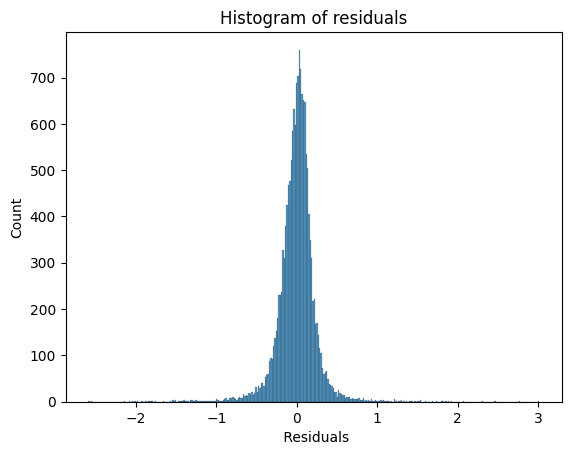

In [87]:
import seaborn as sns

sns.histplot(error)


plt.xlabel(" Residuals")
plt.title("Histogram of residuals")

## SHapiro WIlk test

In [88]:
from scipy import stats

In [89]:
res = stats.shapiro(error)

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 15856.
  res = hypotest_fun_out(*samples, **kwds)


In [90]:
res

ShapiroResult(statistic=np.float64(0.8526019402961729), pvalue=np.float64(2.885426971275825e-80))

In [91]:
res.statistic

np.float64(0.8526019402961729)

In [92]:
 ## Implementation of heteroskedasticity

 ## Implementation of heteroskedasticity

In [93]:
Y_hat = sm_model.predict(X_sm)
errors = Y_hat - y_train

Text(0.5, 1.0, 'Predicted values vs Residuals')

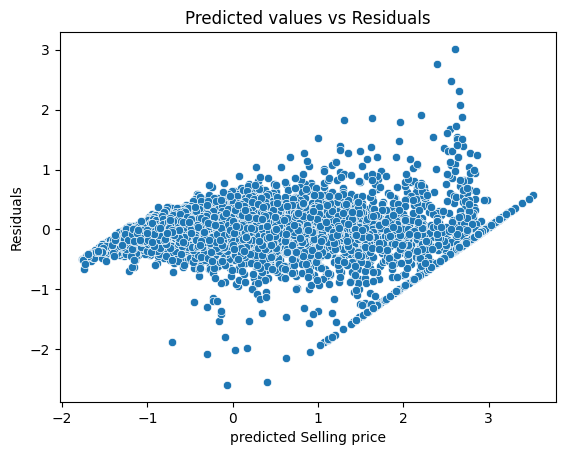

In [94]:
sns.scatterplot(x=Y_hat,y=errors)
plt.xlabel("predicted Selling price")
plt.ylabel("Residuals")
plt.title("Predicted values vs Residuals")